# ¿Puede una IA revisar papers científicos como lo haría un humano?

500 papers de ICLR 2024. Decisiones de revisores humanos. Claude-3.5-Sonnet y GPT-4o evaluaron los mismos papers. Veamos cuánto coinciden — y dónde fallan.

---

**Paper:** Lu et al. (2026) *The AI Scientist: Towards Fully Automated Open-Ended Scientific Discovery.* Nature.
**DOI:** [10.1038/s41586-026-10265-5](https://doi.org/10.1038/s41586-026-10265-5)
**Video:** [Ver en YouTube](https://youtube.com/watch?v=U1Tzpx5wbtM)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-02-ia-scientist-paper-autonomo/notebook.ipynb)

## El benchmark: revisores humanos vs IA

El paper presenta The AI Scientist — un sistema que genera papers científicos de punta a punta. Pero también incluye **The Automated Reviewer**: una IA que evalúa papers como lo haría un revisor de conferencia.

Para medir qué tan bien funciona, usaron 500 papers reales de ICLR 2024 (una de las conferencias más importantes en machine learning). Cada paper fue evaluado por 3-7 revisores humanos y también por modelos de lenguaje (Claude-3.5-Sonnet y GPT-4o). Los scores van de 1 a 10.

¿Cuánto se parecen las evaluaciones de una IA a las de un humano?

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
UMBRAL_ACEPTACION = 6.0     # Score mínimo para considerar "aceptable"
COLOR_CLAUDE = '#7C3AED'    # Violeta — Claude
COLOR_GPT4O = '#059669'     # Emerald — GPT-4o
COLOR_HUMANO = '#2563EB'    # Azul CaM — Humanos
COLOR_RECHAZO = '#DC2626'   # Rojo — Rechazados
FUENTE = 'Fuente: Lu et al. (2026), Nature | Datos: github.com/SakanaAI/AI-Scientist'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os, urllib.request

# Estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Cargar datos
df = pd.read_csv('datos/revisiones_comparadas.csv')
scores_dec = pd.read_csv('datos/scores_por_decision.csv')

print(f"Papers: {len(df)}")
print(f"Aceptados: {df['accepted'].sum()} ({df['accepted'].mean()*100:.1f}%)")
print(f"Rechazados: {(~df['accepted'].astype(bool)).sum()} ({(1-df['accepted'].mean())*100:.1f}%)")
print(f"Revisores por paper: {df['n_reviewers'].median():.0f} (mediana)")

Papers: 500
Aceptados: 184 (36.8%)
Rechazados: 316 (63.2%)
Revisores por paper: 4 (mediana)


## ¿Cuánto coinciden IA y humanos?

Cada punto es un paper. Si la IA fuera perfecta, todos caerían sobre la diagonal.

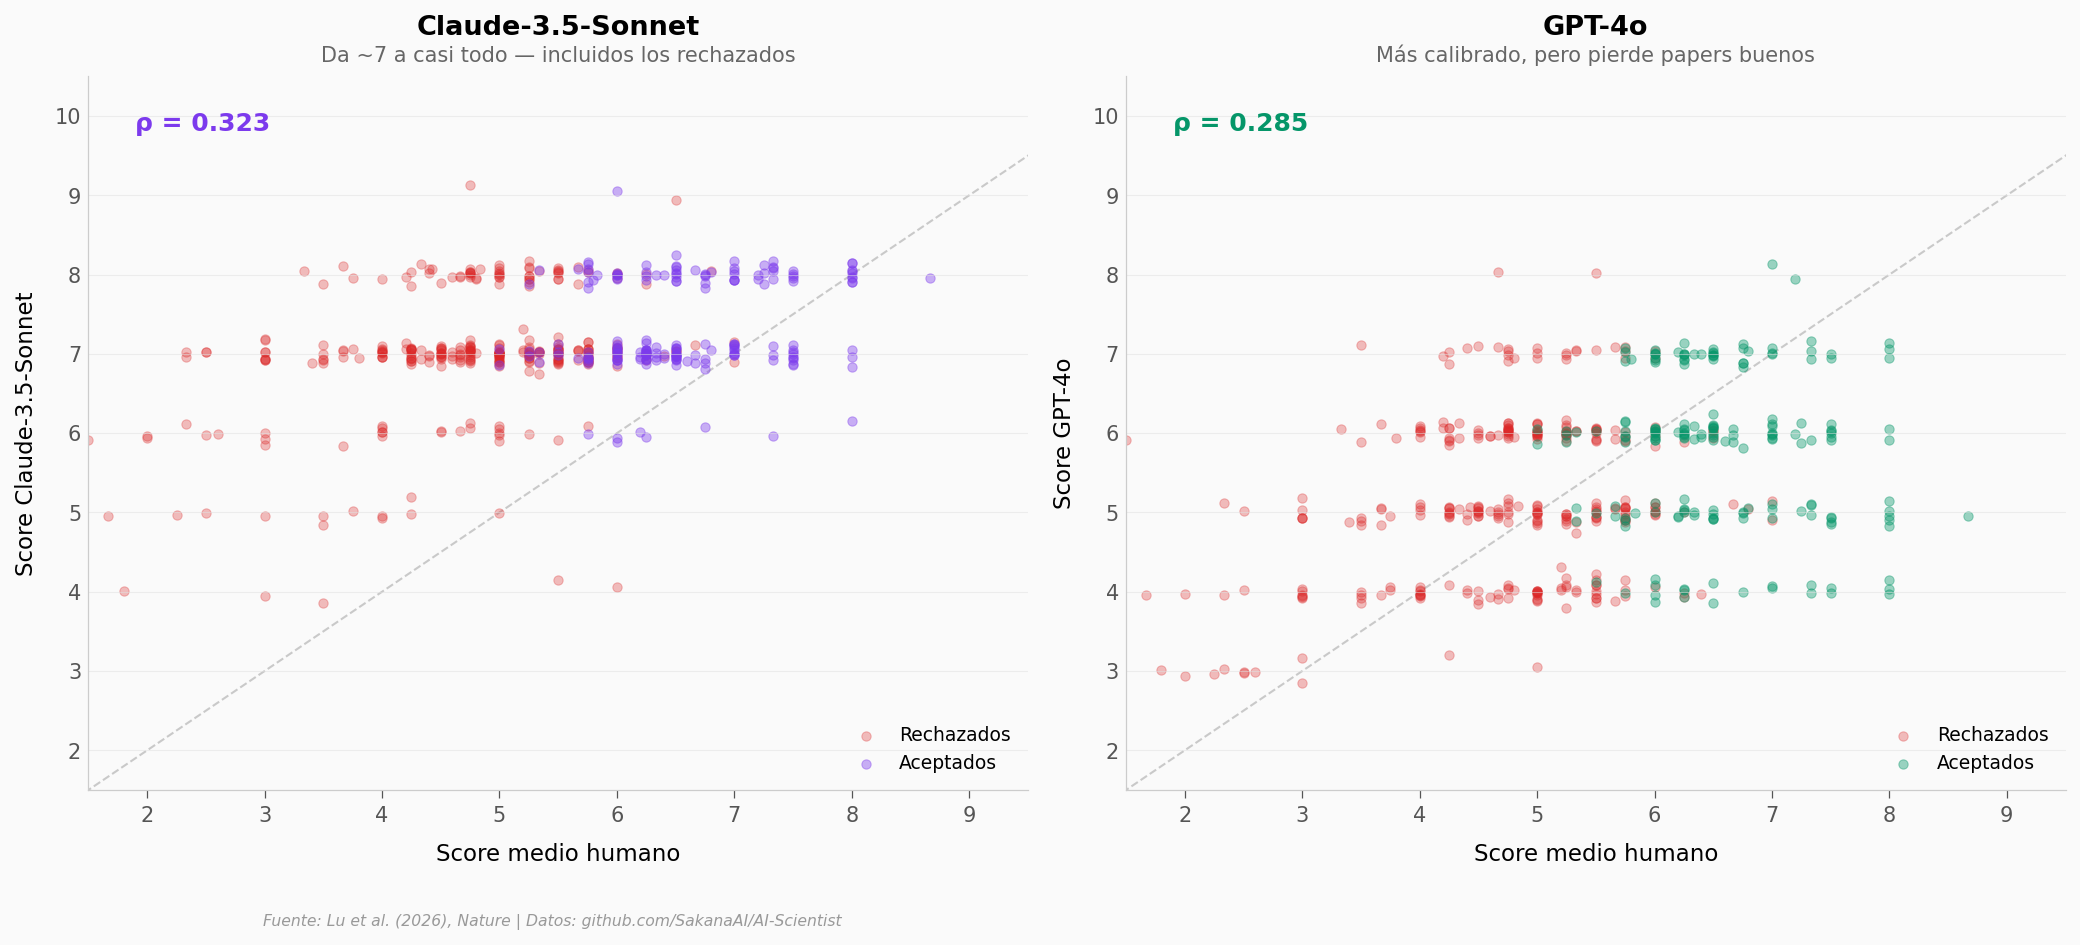

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for ax, model, col, color, name in [
    (ax1, 'claude', 'claude_overall', COLOR_CLAUDE, 'Claude-3.5-Sonnet'),
    (ax2, 'gpt4o', 'gpt4o_overall', COLOR_GPT4O, 'GPT-4o')
]:
    # Separate by decision
    accepted = df[df['accepted'] == 1]
    rejected = df[df['accepted'] == 0]
    
    np.random.seed(42)
    jitter = np.random.normal(0, 0.08, len(df))
    
    ax.scatter(rejected['human_mean'], rejected[col] + jitter[:len(rejected)],
               color=COLOR_RECHAZO, s=20, alpha=0.3, label='Rechazados')
    ax.scatter(accepted['human_mean'], accepted[col] + jitter[len(rejected):len(rejected)+len(accepted)],
               color=color, s=20, alpha=0.4, label='Aceptados')
    
    # Diagonal
    ax.plot([1, 10], [1, 10], '--', color='#999999', linewidth=1, alpha=0.5, zorder=0)
    
    # Correlation
    rho, p = stats.spearmanr(df['human_mean'], df[col])
    ax.text(0.05, 0.95, f'ρ = {rho:.3f}', transform=ax.transAxes,
            fontsize=12, fontweight='bold', color=color, va='top')
    
    ax.set_xlabel('Score medio humano', fontsize=11)
    ax.set_ylabel(f'Score {name}', fontsize=11)
    ax.set_title(name, fontsize=13, fontweight='bold', pad=20)
    ax.set_xlim(1.5, 9.5)
    ax.set_ylim(1.5, 10.5)
    ax.legend(fontsize=9, loc='lower right')

ax1.text(0.5, 1.02, 'Da ~7 a casi todo — incluidos los rechazados',
         transform=ax1.transAxes, fontsize=10, color='#666666', ha='center')
ax2.text(0.5, 1.02, 'Más calibrado, pero pierde papers buenos',
         transform=ax2.transAxes, fontsize=10, color='#666666', ha='center')

plt.tight_layout()
fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/scatter_scores.png', dpi=200, bbox_inches='tight')
plt.show()

La correlación entre IA y humanos es modesta: ρ = 0,323 (Claude) y ρ = 0,285 (GPT-4o). Eso significa que la concordancia entre IA y humanos es baja — los rankings coinciden poco.

Pero lo más llamativo es el patrón de cada modelo. Claude da ~7 a casi todo: su score medio para papers *rechazados por humanos* es 7,00 — apenas por debajo de los aceptados (7,35). GPT-4o es más selectivo (5,17 para rechazados vs 5,79 para aceptados), pero su gap de 0,62 puntos sigue siendo pequeño comparado con el humano (1,82 puntos).

## ¿Aciertan en aceptar o rechazar?

Una cosa es el score numérico. Otra es la decisión binaria: ¿el paper se acepta o se rechaza?

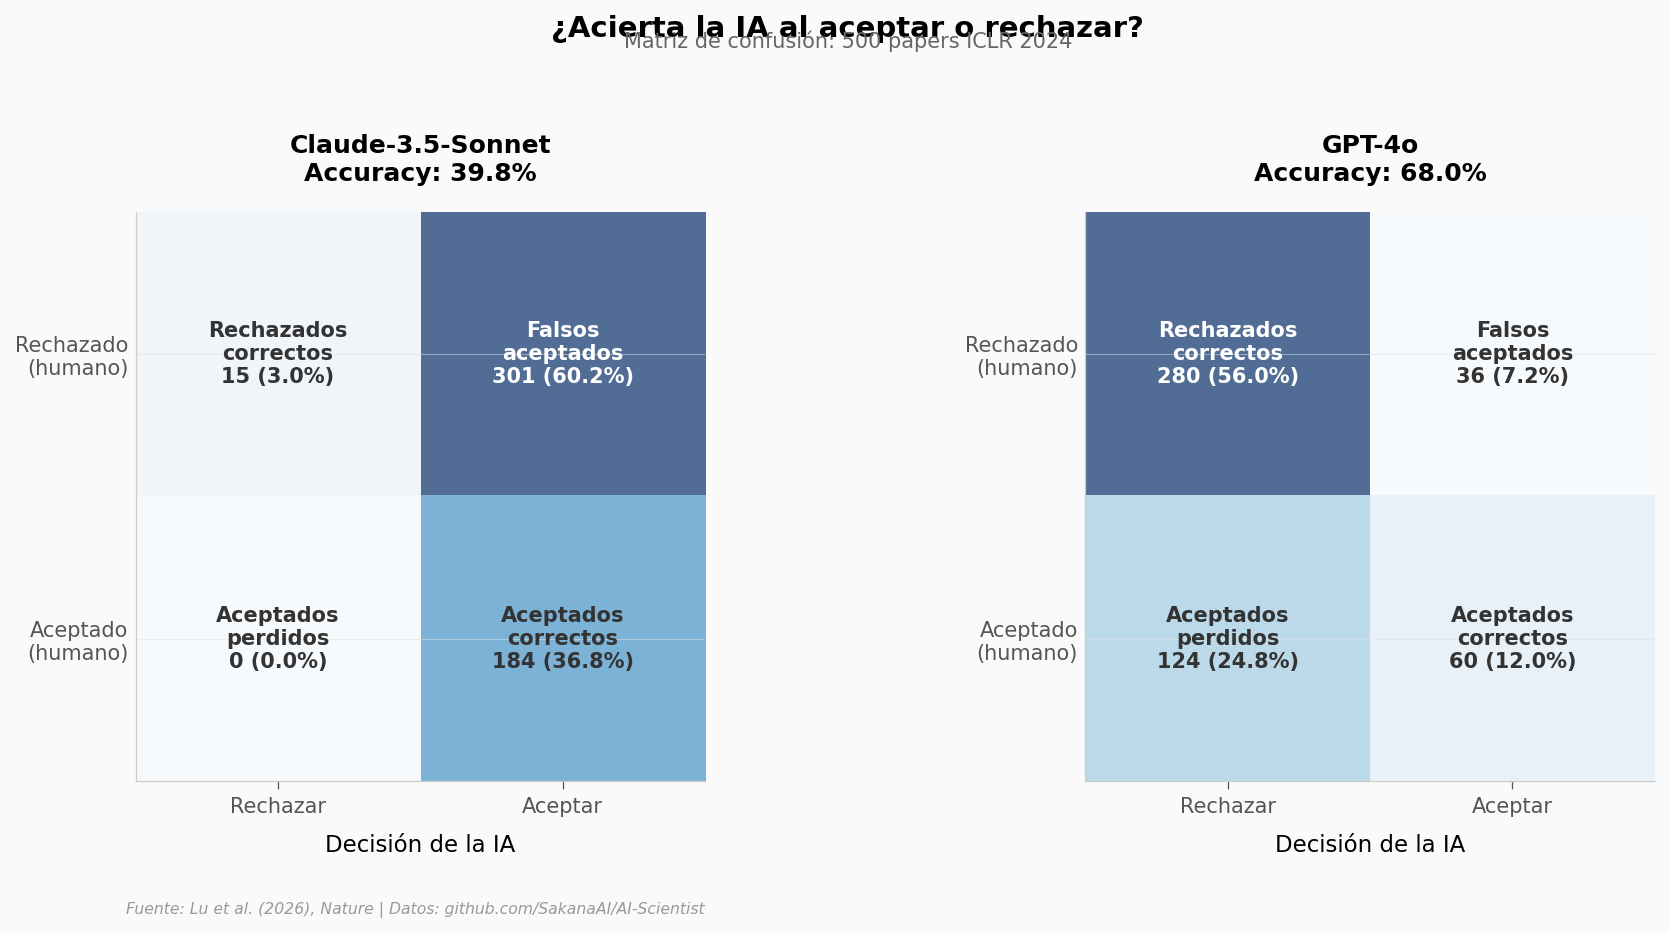

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, col_accept, color, name in [
    (ax1, 'claude_accepted', COLOR_CLAUDE, 'Claude-3.5-Sonnet'),
    (ax2, 'gpt4o_accepted', COLOR_GPT4O, 'GPT-4o')
]:
    tp = ((df['accepted']==1) & (df[col_accept]==1)).sum()
    tn = ((df['accepted']==0) & (df[col_accept]==0)).sum()
    fp = ((df['accepted']==0) & (df[col_accept]==1)).sum()
    fn = ((df['accepted']==1) & (df[col_accept]==0)).sum()
    
    matrix = np.array([[tn, fp], [fn, tp]])
    im = ax.imshow(matrix, cmap='Blues', alpha=0.7)
    
    labels = [['Rechazados\ncorrectos', 'Falsos\naceptados'],
              ['Aceptados\nperdidos', 'Aceptados\ncorrectos']]
    for i in range(2):
        for j in range(2):
            val = matrix[i, j]
            pct = val / len(df) * 100
            text_color = 'white' if val > 200 else '#333333'
            ax.text(j, i, f'{labels[i][j]}\n{val} ({pct:.1f}%)',
                    ha='center', va='center', fontsize=10, fontweight='bold',
                    color=text_color)
    
    acc = (tp + tn) / len(df)
    ax.set_title(f'{name}\nAccuracy: {acc:.1%}', fontsize=12, fontweight='bold', pad=15)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Rechazar', 'Aceptar'], fontsize=10)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Rechazado\n(humano)', 'Aceptado\n(humano)'], fontsize=10)
    ax.set_xlabel('Decisión de la IA', fontsize=11)

fig.suptitle('¿Acierta la IA al aceptar o rechazar?',
             fontsize=14, fontweight='bold', y=1.05)
fig.text(0.5, 1.01, 'Matriz de confusión: 500 papers ICLR 2024',
         fontsize=10, color='#666666', ha='center')

plt.tight_layout()
fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

Dos estrategias opuestas. Claude acepta 485 de 500 papers — nunca pierde un aceptado (recall 100%), pero acepta 301 que deberían haberse rechazado. GPT-4o es conservador: rechaza correctamente 280 de 316, pero se lleva por delante 124 papers que los humanos sí aceptaron.

Si un comité de conferencia usara a Claude como filtro, pasaría casi todo. Si usara a GPT-4o, rechazaría buenos papers.

## ¿Cuántos puntos se desvía cada modelo?

¿Cuántos puntos se desvía cada modelo?

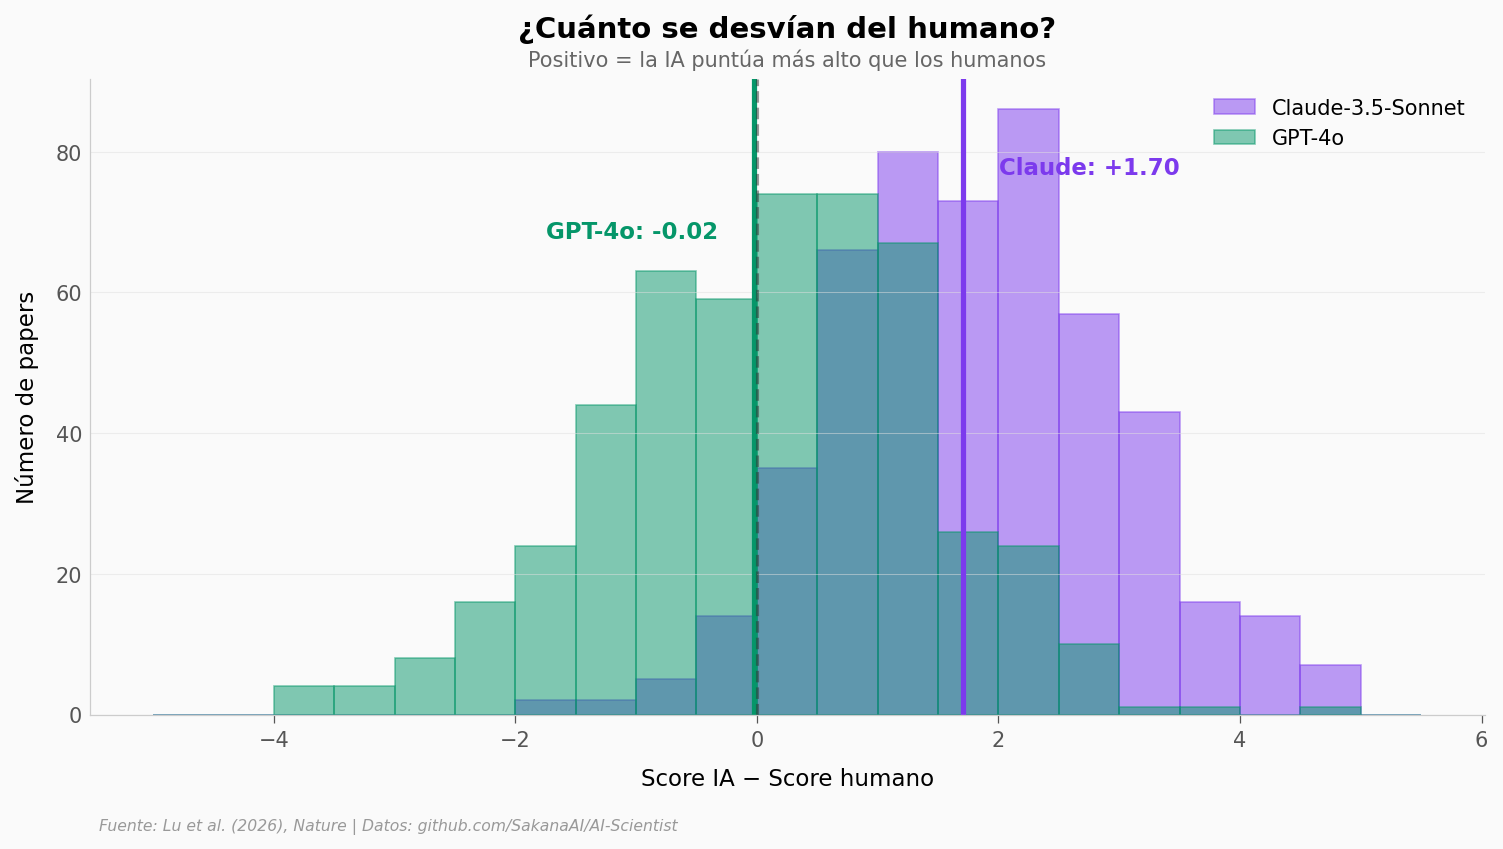

In [4]:
df['diff_claude'] = df['claude_overall'] - df['human_mean']
df['diff_gpt4o'] = df['gpt4o_overall'] - df['human_mean']

fig, ax = plt.subplots(figsize=(12, 5.5))
bins = np.arange(-5, 6, 0.5)

ax.hist(df['diff_claude'], bins=bins, color=COLOR_CLAUDE, alpha=0.5,
        edgecolor=COLOR_CLAUDE, linewidth=0.8, label='Claude-3.5-Sonnet')
ax.hist(df['diff_gpt4o'], bins=bins, color=COLOR_GPT4O, alpha=0.5,
        edgecolor=COLOR_GPT4O, linewidth=0.8, label='GPT-4o')

# Vertical lines at means
mean_c = df['diff_claude'].mean()
mean_g = df['diff_gpt4o'].mean()
ax.axvline(mean_c, color=COLOR_CLAUDE, linewidth=2.5, linestyle='-')
ax.axvline(mean_g, color=COLOR_GPT4O, linewidth=2.5, linestyle='-')
ax.axvline(0, color='#333333', linewidth=1.5, linestyle='--', alpha=0.5)

ax.annotate(f'Claude: +{mean_c:.2f}', xy=(mean_c, ax.get_ylim()[1]*0.85),
            fontsize=11, fontweight='bold', color=COLOR_CLAUDE, ha='left',
            xytext=(mean_c+0.3, ax.get_ylim()[1]*0.85))
ax.annotate(f'GPT-4o: {mean_g:+.2f}', xy=(mean_g, ax.get_ylim()[1]*0.75),
            fontsize=11, fontweight='bold', color=COLOR_GPT4O, ha='right',
            xytext=(mean_g-0.3, ax.get_ylim()[1]*0.75))

ax.set_xlabel('Score IA − Score humano', fontsize=11)
ax.set_ylabel('Número de papers', fontsize=11)
ax.set_title('¿Cuánto se desvían del humano?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Positivo = la IA puntúa más alto que los humanos',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=10, loc='upper right')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/sesgo_scores.png', dpi=200, bbox_inches='tight')
plt.show()

Claude tiene un sesgo sistemático: puntúa +1,70 puntos por encima de los humanos en promedio. En una escala de 1-10, eso es enorme — equivale a dar un aprobado a un paper que los humanos consideran mediocre. GPT-4o está centrado en cero (sesgo de −0,02), pero tiene más dispersión (σ = 1,35): en un 8% de papers se desvía 3+ puntos.

## ¿Para qué tipo de papers falla más?

Veamos cómo le va a cada modelo según la categoría de decisión humana.

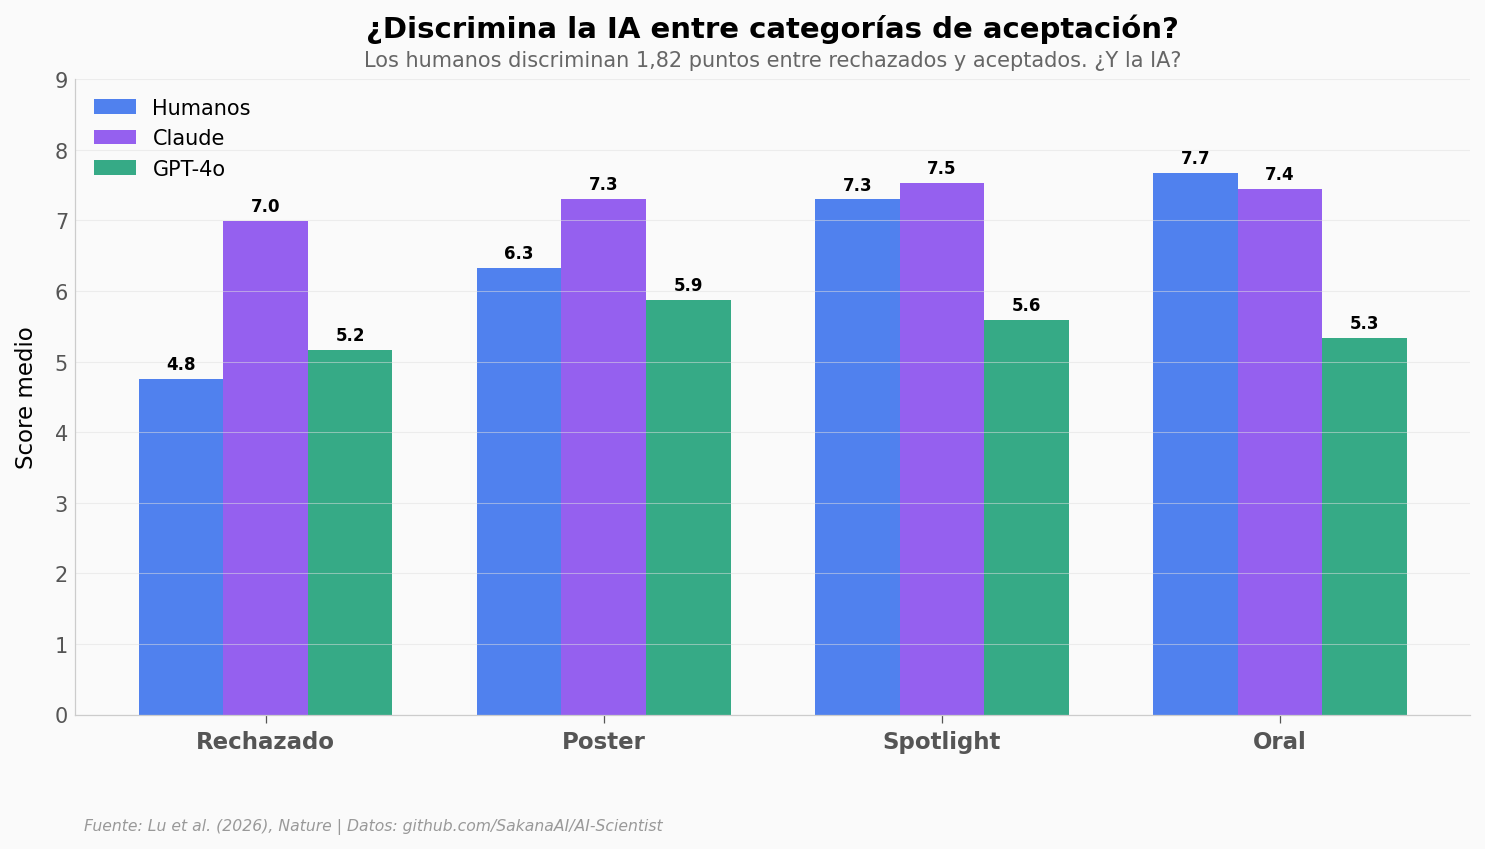

In [5]:
fig, ax = plt.subplots(figsize=(12, 5.5))

categories = ['Reject', 'Accept (Poster)', 'Accept (Spotlight)', 'Accept (Oral)']
cat_labels = ['Rechazado', 'Poster', 'Spotlight', 'Oral']
x = np.arange(len(categories))
width = 0.25

human_means = [df[df['decision']==c]['human_mean'].mean() for c in categories]
claude_means = [df[df['decision']==c]['claude_overall'].mean() for c in categories]
gpt4o_means = [df[df['decision']==c]['gpt4o_overall'].mean() for c in categories]

bars1 = ax.bar(x - width, human_means, width, color=COLOR_HUMANO, alpha=0.8, label='Humanos')
bars2 = ax.bar(x, claude_means, width, color=COLOR_CLAUDE, alpha=0.8, label='Claude')
bars3 = ax.bar(x + width, gpt4o_means, width, color=COLOR_GPT4O, alpha=0.8, label='GPT-4o')

# Inline values
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.08,
                f'{height:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(cat_labels, fontsize=11, fontweight='bold')
ax.set_ylabel('Score medio', fontsize=11)
ax.set_ylim(0, 9)
ax.legend(fontsize=10, loc='upper left')
ax.set_title('¿Discrimina la IA entre categorías de aceptación?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Los humanos discriminan 1,82 puntos entre rechazados y aceptados. ¿Y la IA?',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/scores_por_categoria.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| La correlación entre IA y humanos es modesta | ✅ | ρ = 0,323 (Claude), 0,285 (GPT-4o). Significativas (p < 10⁻¹⁰). Correlaciones modestas — para referencia, ρ² = 0,10 (Claude) y 0,08 (GPT-4o) |
| Claude acepta casi todo | ✅ | 485/500 aceptados. Solo rechaza 15 papers. Recall = 100%, Precision = 37,9% |
| GPT-4o es más selectivo pero pierde papers buenos | ✅ | Accuracy 68%, pero recall = 32,6%. Pierde 124 de 184 aceptados |
| Claude tiene sesgo positivo sistemático | ✅ | +1,70 puntos de media. Da 7,00 a rechazados (humanos: 4,75) |
| GPT-4o está mejor calibrado en media | ✅ | Sesgo = −0,02. Pero dispersión mayor (σ = 1,35 vs 1,18 de Claude) |
| Ninguna IA discrimina bien entre categorías | ✅ | Humanos: gap de 1,82 puntos. Claude: 0,36. GPT-4o: 0,62 |

> **Limitaciones:** (1) Solo 500 papers de ICLR 2024 — una conferencia de ML, no representativa de toda la ciencia. (2) Los modelos usaron configuración específica (reflect+ensemble para Claude, reflect+ensemble para GPT-4o). Otros prompts o configuraciones podrían dar resultados diferentes. (3) Este benchmark evalúa al *Automated Reviewer* (parte 2 del paper), no la calidad de los papers *generados* por The AI Scientist (parte 1).

---

## Ahora tú

1. **¿Hay un umbral mejor?** Cambia `UMBRAL_ACEPTACION` en la celda de configuración. Si usas el score de Claude >7 para aceptar, ¿mejora la accuracy?
2. **¿Qué paper tiene la mayor discrepancia?** Busca el paper donde la diferencia Claude-humano es máxima. ¿Qué score le dieron los humanos?
3. **Otros sub-scores:** El dataset tiene `claude_soundness`, `claude_originality`, etc. ¿Cuál de estos sub-scores tiene mayor correlación con la decisión humana?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Con qué umbral de score de Claude se maximiza la accuracy?

best_acc = 0
best_threshold = 0

for threshold in np.arange(5.0, 9.5, 0.5):
    predicted_accept = (df['claude_overall'] >= threshold).astype(int)
    acc = (predicted_accept == df['accepted']).mean()
    if acc > best_acc:
        best_acc = acc
        best_threshold = threshold

print(f"Mejor umbral para Claude: ≥ {best_threshold}")
print(f"Accuracy con ese umbral: {best_acc:.1%}")
print()

# Comparar con GPT-4o
for threshold in np.arange(3.0, 9.0, 0.5):
    predicted_accept = (df['gpt4o_overall'] >= threshold).astype(int)
    acc = (predicted_accept == df['accepted']).mean()
    if acc > best_acc:
        best_acc = acc
        best_threshold = threshold
        print(f"  GPT-4o @ ≥{threshold}: accuracy = {acc:.1%}")

# Sub-score más predictivo
print(f"\nCorrelación de sub-scores de Claude con decisión humana:")
for col in ['claude_soundness', 'claude_originality', 'claude_quality',
            'claude_clarity', 'claude_significance', 'claude_contribution']:
    rho, p = stats.spearmanr(df[col], df['accepted'])
    print(f"  {col.replace('claude_', ''):15}: ρ = {rho:.3f}")

Mejor umbral para Claude: ≥ 7.5
Accuracy con ese umbral: 64.8%

  GPT-4o @ ≥6.5: accuracy = 66.8%

Correlación de sub-scores de Claude con decisión humana:
  soundness      : ρ = 0.257
  originality    : ρ = 0.110
  quality        : ρ = 0.232
  clarity        : ρ = 0.154
  significance   : ρ = 0.162
  contribution   : ρ = 0.235


---

**Datos:** Benchmark de revisión automatizada del repositorio AI-Scientist (SakanaAI). 500 papers ICLR 2024 con scores de revisores humanos y revisiones de Claude-3.5-Sonnet y GPT-4o.
**Paper:** [10.1038/s41586-026-10265-5](https://doi.org/10.1038/s41586-026-10265-5)
**Código:** [github.com/SakanaAI/AI-Scientist](https://github.com/SakanaAI/AI-Scientist)
**Licencia:** Apache 2.0 (código), datos bajo licencia original del paper.
**Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)